<a href="https://colab.research.google.com/github/abyansyah052/NLP-1/blob/main/Week4_Assignment/TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install xgboost tensorflow tensorflow_hub torch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

is_cuda = torch.cuda.is_available()
device = torch.device("cuda" if is_cuda else "cpu")
print("GPU available" if is_cuda else "CPU used")

CPU used


In [3]:
df = pd.read_csv('/content/Tugas 1A Clean Data.csv')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Shape: {df.shape}")
df.head()

Shape: (59965, 5)


,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,si bagus coba daftar login pdhl isi nik bnr se...,1,0.0,0.0,Negative
1,cepat bantu,5,0.0,0.0,Positive
2,mamtap,5,0.0,0.0,Positive
3,mantap 100 percaya,5,0.0,0.0,Positive
4,bagus bangett,5,0.0,0.0,Positive


In [4]:
def sentiment_label(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['score'].apply(sentiment_label)
print(df['sentiment'].value_counts())

x = df['content'].fillna('').astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])
print(f"Label classes: {label_encoder.classes_}")

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Train: {len(xtrain)}, Test: {len(xtest)}")

sentiment
positive    38421
negative    18654
neutral      2890
Name: count, dtype: int64
Label classes: ['negative' 'neutral' 'positive']
Train: 47972, Test: 11993


In [5]:
from collections import Counter

all_words = []
for text in xtrain:
    for word in str(text).split():
        all_words.append(word)

word_freq = Counter(all_words)
sorted_vocab = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

print(f"Total unique words (raw vocab): {len(word_freq)}")
print("\nTop 20 kata paling sering:")
for word, count in sorted_vocab[:20]:
    print(f"  {word}: {count}")

print("\nBottom 20 kata paling jarang:")
for word, count in sorted_vocab[-20:]:
    print(f"  {word}: {count}")

Total unique words (raw vocab): 5673

Top 20 kata paling sering:
  bagus: 5743
  mantap: 4983
  mudah: 3973
  akun: 3752
  masuk: 3634
  bantu: 3390
  banget: 3366
  login: 3347
  transaksi: 3200
  uang: 3124
  saldo: 2640
  tolong: 2454
  daftar: 2443
  transfer: 2012
  kasih: 1940
  hp: 1926
  ribet: 1832
  pakai: 1831
  salah: 1810
  buka: 1756

Bottom 20 kata paling jarang:
  mnggu: 1
  deal: 1
  ding: 1
  sndi: 1
  soo: 1
  paruh: 1
  survey: 1
  beritahu: 1
  akirnya: 1
  kuta: 1
  janga: 1
  jelekkkkkk: 1
  gabakal: 1
  ba: 1
  maw: 1
  roting: 1
  bukalapak: 1
  wak: 1
  rewel: 1
  ampunnn: 1


In [6]:
MIN_FREQ = 3
MAX_FREQ_RATIO = 0.9  # kata yang muncul di >90% dokumen juga dibuang (terlalu umum)

total_docs = len(xtrain)

vocab_filtered = {
    word: count for word, count in word_freq.items()
    if count >= MIN_FREQ and (count / total_docs) < MAX_FREQ_RATIO
}

print(f"Vocab sebelum cutoff : {len(word_freq)}")
print(f"Vocab setelah cutoff : {len(vocab_filtered)}")
print(f"Kata dibuang         : {len(word_freq) - len(vocab_filtered)}")

# Word to number mapping (sorted by freq)
sorted_filtered = sorted(vocab_filtered.items(), key=lambda x: x[1], reverse=True)
word_to_number  = {word: i+1 for i, (word, _) in enumerate(sorted_filtered)}

print(f"\nTop 10 vocab setelah cutoff:")
for word, idx in list(word_to_number.items())[:10]:
    print(f"  [{idx}] {word}: {vocab_filtered[word]}x")

Vocab sebelum cutoff : 5673
Vocab setelah cutoff : 4945
Kata dibuang         : 728

Top 10 vocab setelah cutoff:
  [1] bagus: 5743x
  [2] mantap: 4983x
  [3] mudah: 3973x
  [4] akun: 3752x
  [5] masuk: 3634x
  [6] bantu: 3390x
  [7] banget: 3366x
  [8] login: 3347x
  [9] transaksi: 3200x
  [10] uang: 3124x


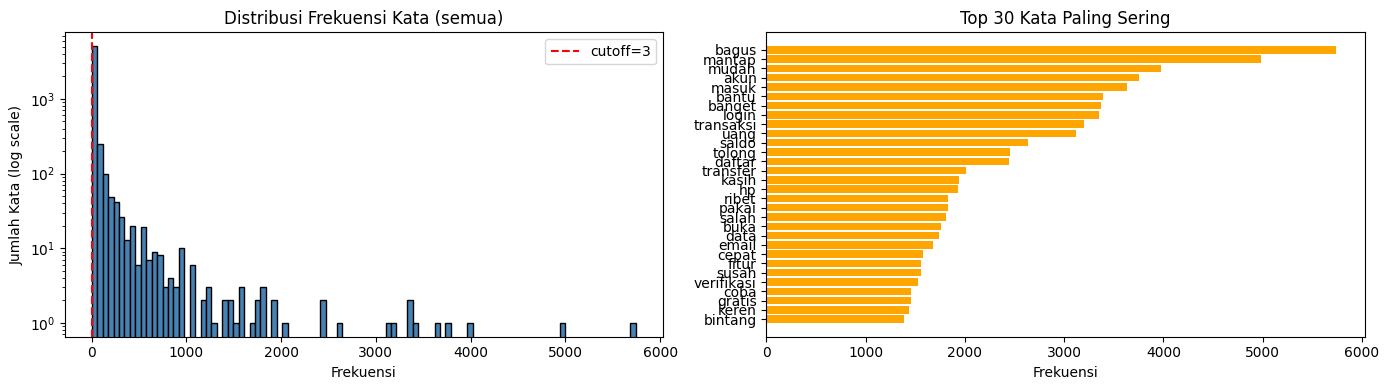

In [7]:
freqs = list(word_freq.values())

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(freqs, bins=100, color='steelblue', edgecolor='black')
plt.yscale('log')
plt.title('Distribusi Frekuensi Kata (semua)')
plt.xlabel('Frekuensi')
plt.ylabel('Jumlah Kata (log scale)')
plt.axvline(MIN_FREQ, color='red', linestyle='--', label=f'cutoff={MIN_FREQ}')
plt.legend()

# Top 30 kata
top30 = pd.DataFrame(sorted_vocab[:30], columns=['Word', 'Count'])
plt.subplot(1, 2, 2)
plt.barh(top30['Word'][::-1], top30['Count'][::-1], color='orange')
plt.title('Top 30 Kata Paling Sering')
plt.xlabel('Frekuensi')

plt.tight_layout()
plt.show()

In [8]:
svm_clf = LinearSVC()
lr_clf  = LogisticRegression(max_iter=1000)
nb_clf  = MultinomialNB()
xgb_clf = XGBClassifier(eval_metric='mlogloss', verbosity=0)
rfc_clf = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt',
                                  min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=42)

def evaluate_model(model, xtest, ytest):
    y_pred    = model.predict(xtest)
    accuracy  = accuracy_score(ytest, y_pred)
    precision = precision_score(ytest, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(ytest, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(ytest, y_pred, average='weighted', zero_division=0)
    report    = classification_report(ytest, y_pred, zero_division=0)
    cm        = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from timeit import default_timer as timer

# Fix: index vocab mulai dari 0
word_to_number_fixed = {word: i for i, (word, _) in enumerate(sorted_filtered)}

tfidf = TfidfVectorizer(
    vocabulary=word_to_number_fixed,
    sublinear_tf=True
)

start = timer()
xtrain_tfidf = tfidf.fit_transform(xtrain).toarray()
print(f"TF-IDF train: {xtrain_tfidf.shape} | time: {timer()-start:.2f}s")

start = timer()
xtest_tfidf = tfidf.transform(xtest).toarray()
print(f"TF-IDF test : {xtest_tfidf.shape} | time: {timer()-start:.2f}s")

# Top kata by mean TF-IDF score
feature_names = tfidf.get_feature_names_out()
mean_tfidf    = xtrain_tfidf.mean(axis=0)
top_tfidf_df  = pd.DataFrame({'Word': feature_names, 'Mean TF-IDF': mean_tfidf})
top_tfidf_df  = top_tfidf_df.sort_values('Mean TF-IDF', ascending=False).head(20)

print("\nTop 20 kata by TF-IDF score:")
print(top_tfidf_df.to_string(index=False))

TF-IDF train: (47972, 4945) | time: 1.13s
TF-IDF test : (11993, 4945) | time: 0.51s

Top 20 kata by TF-IDF score:
     Word  Mean TF-IDF
   mantap     0.074182
    bagus     0.069594
    bantu     0.034746
    mudah     0.030985
   banget     0.022501
transaksi     0.019722
    keren     0.018784
    login     0.017034
    masuk     0.016128
     akun     0.015904
     uang     0.014724
    cepat     0.013240
   daftar     0.012571
    ribet     0.012455
    kasih     0.012230
     coba     0.012070
   tolong     0.011768
    saldo     0.011177
 transfer     0.010742
    susah     0.010131


In [10]:
start = timer(); svm_tfidf = svm_clf.fit(xtrain_tfidf, ytrain); print(f"SVM : {timer()-start:.2f}s")
start = timer(); lr_tfidf  = lr_clf.fit(xtrain_tfidf, ytrain);  print(f"LR  : {timer()-start:.2f}s")
start = timer(); nb_tfidf  = nb_clf.fit(xtrain_tfidf, ytrain);  print(f"NB  : {timer()-start:.2f}s")
start = timer(); xgb_tfidf = xgb_clf.fit(xtrain_tfidf, ytrain); print(f"XGB : {timer()-start:.2f}s")
start = timer(); rfc_tfidf = rfc_clf.fit(xtrain_tfidf, ytrain); print(f"RFC : {timer()-start:.2f}s")

SVM : 12.70s
LR  : 112.62s
NB  : 0.58s
XGB : 158.54s
RFC : 12.47s


In [11]:
_, acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm   = evaluate_model(svm_tfidf,  xtest_tfidf, ytest)
_, acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr    = evaluate_model(lr_tfidf,   xtest_tfidf, ytest)
_, acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb    = evaluate_model(nb_tfidf,   xtest_tfidf, ytest)
_, acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb  = evaluate_model(xgb_tfidf,  xtest_tfidf, ytest)
_, acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc   = evaluate_model(rfc_tfidf,  xtest_tfidf, ytest)

models_tfidf = {
    'LinearSVM'         : (acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm),
    'LogisticRegression': (acc_lr,  prec_lr,  rec_lr,  f1_lr,  rep_lr,  cm_lr),
    'NaiveBayes'        : (acc_nb,  prec_nb,  rec_nb,  f1_nb,  rep_nb,  cm_nb),
    'XGBoost'           : (acc_xgb, prec_xgb, rec_xgb, f1_xgb, rep_xgb, cm_xgb),
    'RandomForest'      : (acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc),
}

for name, (acc, prec, rec, f1, rep, cm) in models_tfidf.items():
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.2f}")
    print(f"  Precision: {prec:.2f}")
    print(f"  Recall   : {rec:.2f}")
    print(f"  F1 Score : {f1:.2f}")
    print("  Classification Report:")
    print(rep)
    print("  Confusion Matrix:")
    print(cm)


  LinearSVM
  Accuracy : 0.85
  Precision: 0.82
  Recall   : 0.85
  F1 Score : 0.83
  Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80      3668
           1       0.13      0.01      0.02       579
           2       0.90      0.92      0.91      7746

    accuracy                           0.85     11993
   macro avg       0.60      0.59      0.58     11993
weighted avg       0.82      0.85      0.83     11993

  Confusion Matrix:
[[3062   26  580]
 [ 320    7  252]
 [ 608   21 7117]]

  LogisticRegression
  Accuracy : 0.86
  Precision: 0.83
  Recall   : 0.86
  F1 Score : 0.84
  Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      3668
           1       0.33      0.01      0.02       579
           2       0.90      0.93      0.91      7746

    accuracy                           0.86     11993
   macro avg       0.67      0.59      0.58

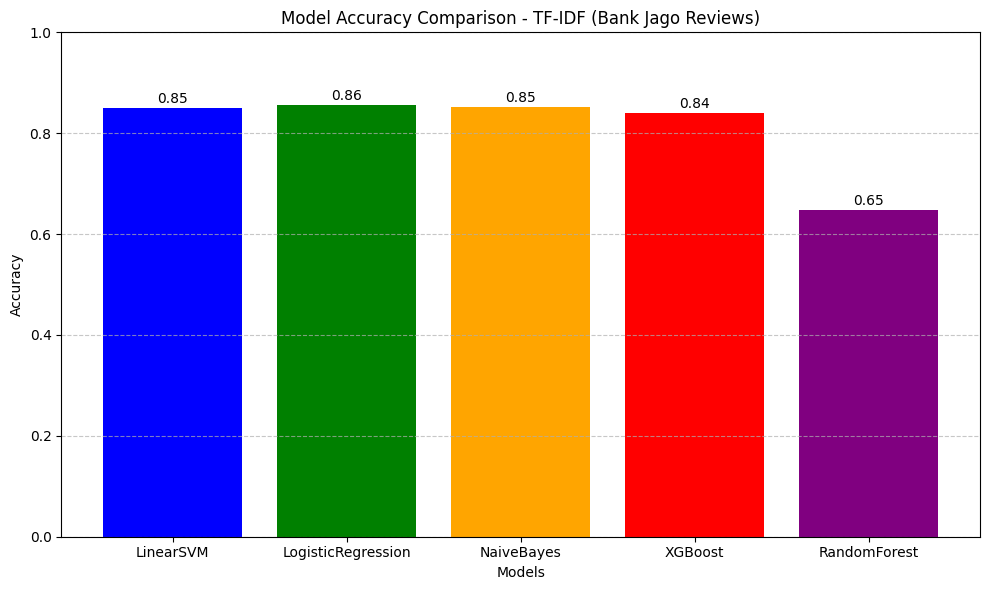

In [12]:
model_names = list(models_tfidf.keys())
model_accs  = [v[0] for v in models_tfidf.values()]

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accs, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison - TF-IDF (Bank Jago Reviews)")
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(model_accs):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
import tensorflow_hub as hub

batch_size = 1000

print("Loading USE model...")
start = timer()
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print(f"USE loaded: {timer()-start:.2f}s")

xtrain_list = xtrain.tolist()
xtest_list  = xtest.tolist()

xtrain_use = []
for i in range(0, len(xtrain_list), batch_size):
    batch = xtrain_list[i:i+batch_size]
    xtrain_use.extend(np.array(embed(batch)))
print(f"xtrain embedded: {len(xtrain_use)}")

xtest_use = []
for i in range(0, len(xtest_list), batch_size):
    batch = xtest_list[i:i+batch_size]
    xtest_use.extend(np.array(embed(batch)))
print(f"xtest embedded: {len(xtest_use)}")

Loading USE model...
USE loaded: 10.41s
xtrain embedded: 47972
xtest embedded: 11993


In [14]:
start = timer(); svm_use = svm_clf.fit(xtrain_use, ytrain);  print(f"SVM : {timer()-start:.2f}s")
start = timer(); lr_use  = lr_clf.fit(xtrain_use, ytrain);   print(f"LR  : {timer()-start:.2f}s")
start = timer(); xgb_use = xgb_clf.fit(xtrain_use, ytrain);  print(f"XGB : {timer()-start:.2f}s")
start = timer(); rfc_use = rfc_clf.fit(xtrain_use, ytrain);  print(f"RFC : {timer()-start:.2f}s")

_, acc_svm_use, _, _, _, rep_svm_use, cm_svm_use = evaluate_model(svm_use, xtest_use, ytest)
_, acc_lr_use,  _, _, _, rep_lr_use,  cm_lr_use  = evaluate_model(lr_use,  xtest_use, ytest)
_, acc_xgb_use, _, _, _, rep_xgb_use, cm_xgb_use = evaluate_model(xgb_use, xtest_use, ytest)
_, acc_rfc_use, _, _, _, rep_rfc_use, cm_rfc_use  = evaluate_model(rfc_use, xtest_use, ytest)

for name, acc, rep, cm in [
    ("SVM USE",  acc_svm_use, rep_svm_use, cm_svm_use),
    ("LR USE",   acc_lr_use,  rep_lr_use,  cm_lr_use),
    ("XGB USE",  acc_xgb_use, rep_xgb_use, cm_xgb_use),
    ("RFC USE",  acc_rfc_use, rep_rfc_use, cm_rfc_use),
]:
    print(f"\n{'='*40}\n  {name}\n  Accuracy: {acc:.2f}")
    print(rep)
    print(cm)

SVM : 53.64s
LR  : 14.09s
XGB : 99.65s
RFC : 29.30s

  SVM USE
  Accuracy: 0.80
              precision    recall  f1-score   support

           0       0.70      0.71      0.71      3668
           1       0.00      0.00      0.00       579
           2       0.84      0.90      0.87      7746

    accuracy                           0.80     11993
   macro avg       0.51      0.54      0.52     11993
weighted avg       0.76      0.80      0.78     11993

[[2604    0 1064]
 [ 303    0  276]
 [ 806    0 6940]]

  LR USE
  Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.70      0.71      0.70      3668
           1       1.00      0.00      0.00       579
           2       0.84      0.89      0.86      7746

    accuracy                           0.79     11993
   macro avg       0.84      0.53      0.52     11993
weighted avg       0.80      0.79      0.77     11993

[[2587    0 1081]
 [ 301    1  277]
 [ 825    0 6921]]

  XGB USE
  Accuracy

In [15]:
import tensorflow as tf

xtrain_combined = tf.concat([tfidf_vectorizer_xtrain if 'tfidf_vectorizer_xtrain' in dir() else xtrain_tfidf, xtrain_use], axis=1)
xtest_combined  = tf.concat([tfidf_vectorizer_xtest  if 'tfidf_vectorizer_xtest'  in dir() else xtest_tfidf,  xtest_use],  axis=1)

start = timer(); svm_comb = svm_clf.fit(xtrain_combined, ytrain);  print(f"SVM : {timer()-start:.2f}s")
start = timer(); lr_comb  = lr_clf.fit(xtrain_combined, ytrain);   print(f"LR  : {timer()-start:.2f}s")
start = timer(); xgb_comb = xgb_clf.fit(xtrain_combined, ytrain);  print(f"XGB : {timer()-start:.2f}s")
start = timer(); rfc_comb = rfc_clf.fit(xtrain_combined, ytrain);  print(f"RFC : {timer()-start:.2f}s")

_, acc_svm_comb, _, _, _, _, _ = evaluate_model(svm_comb, xtest_combined, ytest)
_, acc_lr_comb,  _, _, _, _, _ = evaluate_model(lr_comb,  xtest_combined, ytest)
_, acc_xgb_comb, _, _, _, _, _ = evaluate_model(xgb_comb, xtest_combined, ytest)
_, acc_rfc_comb, _, _, _, _, _ = evaluate_model(rfc_comb, xtest_combined, ytest)

SVM : 220.90s
LR  : 139.62s
XGB : 270.85s
RFC : 31.93s


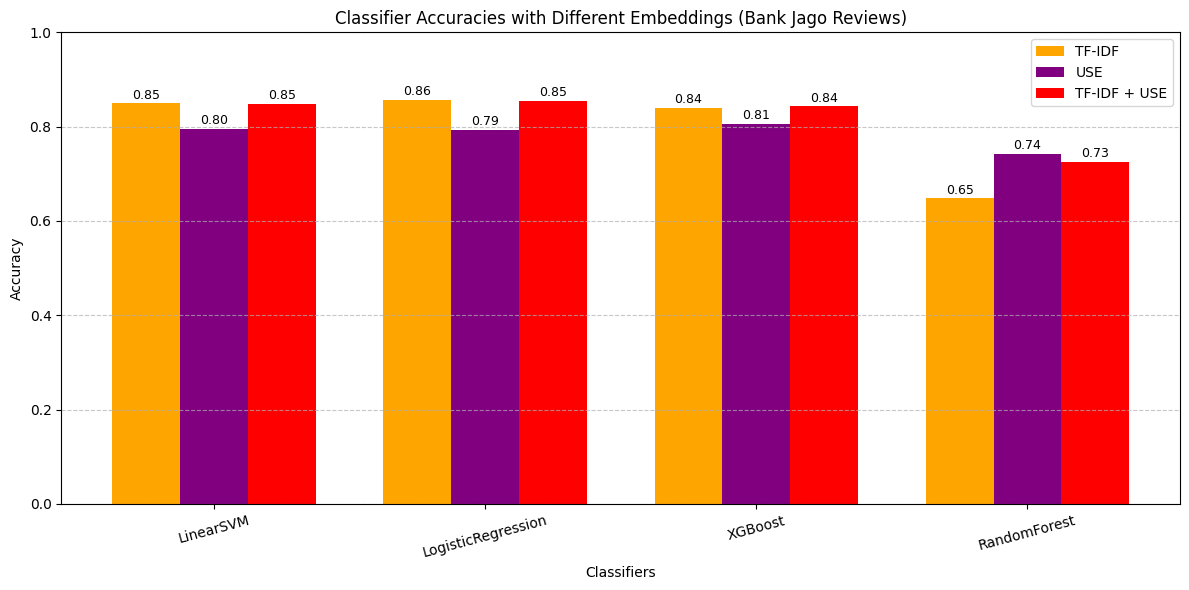

In [16]:

classifiers = ["LinearSVM", "LogisticRegression", "XGBoost", "RandomForest"]

tfidf_accs = [acc_svm, acc_lr, acc_xgb, acc_rfc]
use_accs   = [acc_svm_use, acc_lr_use, acc_xgb_use, acc_rfc_use]
comb_accs  = [acc_svm_comb, acc_lr_comb, acc_xgb_comb, acc_rfc_comb]

x         = np.arange(len(classifiers))
bar_width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - bar_width, tfidf_accs, bar_width, label='TF-IDF',       color='orange')
plt.bar(x,             use_accs,   bar_width, label='USE',           color='purple')
plt.bar(x + bar_width, comb_accs,  bar_width, label='TF-IDF + USE',  color='red')

plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings (Bank Jago Reviews)')
plt.xticks(x, classifiers, rotation=15)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accs[i] + 0.01, f"{tfidf_accs[i]:.2f}", ha='center', fontsize=9)
    plt.text(x[i],             use_accs[i]   + 0.01, f"{use_accs[i]:.2f}",   ha='center', fontsize=9)
    plt.text(x[i] + bar_width, comb_accs[i]  + 0.01, f"{comb_accs[i]:.2f}",  ha='center', fontsize=9)

plt.tight_layout()
plt.show()